# Gradient Boosted Trees: Algorithms 10.3 & 10.4
# From *The Elements of Statistical Learning* — Hastie, Tibshirani, Friedman

**Implementation from scratch** of:
- **Algorithm 10.3**: Gradient Tree Boosting (Regression)
- **Algorithm 10.4**: Gradient Boosting for $K$-class Classification

# Anuj Rajan Lalla (B22AI061)
# Abhinav Swami (B22AI003)

# Interpretation of all the figures and numbers in report

---
# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    make_friedman1,
    load_digits, load_wine
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, log_loss, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
# Part 1: Algorithm 10.3 — Gradient Tree Boosting (Regression)

<!-- ## 1.1 Algorithm Description

The Gradient Tree Boosting algorithm builds an additive model of the form:

$$\hat{f}(x) = f_M(x) = \sum_{m=0}^{M} T(x; \Theta_m)$$

where each $T(x; \Theta_m)$ is a regression tree with parameters $\Theta_m = \{R_{jm}, \gamma_{jm}\}$ (regions and leaf values).

The algorithm proceeds as follows:

**1. Initialize** with a constant model:

$$f_0(x) = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)$$

For squared error loss, this is simply the mean of $y$.

**2. For $m = 1$ to $M$:**

**(a)** Compute the pseudo-residuals (negative gradient of the loss evaluated at the current model):

$$r_{im} = -\left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f = f_{m-1}}$$

For squared error loss $L = \frac{1}{2}(y - f)^2$, the negative gradient is simply the residual $y_i - f_{m-1}(x_i)$.

**(b)** Fit a regression tree to the pseudo-residuals $r_{im}$, giving terminal regions $R_{jm}$, $j = 1, 2, \ldots, J_m$.

**(c)** For each terminal region $j$, solve for the optimal leaf value:

$$\gamma_{jm} = \arg\min_{\gamma} \sum_{x_i \in R_{jm}} L(y_i, f_{m-1}(x_i) + \gamma)$$

For squared error, this is the mean of the residuals in that region. For other losses (absolute error, Huber), this requires a different computation.

**(d)** Update the model:

$$f_m(x) = f_{m-1}(x) + \nu \sum_{j=1}^{J_m} \gamma_{jm} I(x \in R_{jm})$$

where $\nu \in (0, 1]$ is the **shrinkage** (learning rate) parameter.

**3. Output** $\hat{f}(x) = f_M(x)$. -->

## 1.1 Loss Functions for Regression

We implement three loss functions, each with different robustness properties:

| Loss | $L(y, f)$ | Negative Gradient $-\partial L / \partial f$ | Optimal Leaf Value |
|------|-----------|----------------------------------------------|--------------------|
| Squared Error | $\frac{1}{2}(y - f)^2$ | $y - f$ | Mean of residuals |
| Absolute Error | $|y - f|$ | $\text{sign}(y - f)$ | Median of residuals |
| Huber ($\delta$) | $\begin{cases} \frac{1}{2}(y-f)^2 & |y-f| \leq \delta \\ \delta|y-f| - \frac{\delta^2}{2} & \text{otherwise} \end{cases}$ | $\begin{cases} y - f & |y-f| \leq \delta_m \\ \delta_m \cdot \text{sign}(y-f) & \text{otherwise} \end{cases}$ | Median-based |

The Huber loss transitions from squared error (for small residuals) to absolute error (for large residuals), making it robust to outliers while maintaining efficiency near the center.

## 1.2 Implementation

### Loss Function Classes

Each loss function implements:
- `loss(y, f)`: compute the loss value
- `negative_gradient(y, f)`: compute $r_{im} = -\partial L / \partial f$
- `optimal_leaf_value(y, f, terminal_region)`: solve $\gamma_{jm} = \arg\min_\gamma \sum_{x_i \in R_{jm}} L(y_i, f_{m-1}(x_i) + \gamma)$

In [ ]:
class SquaredErrorLoss:
    """L(y, f) = 0.5 * (y - f)^2"""

    def loss(self, y, f):
        return 0.5 * np.mean((y - f) ** 2)

    def negative_gradient(self, y, f):
        return y - f

    def optimal_leaf_value(self, y, f, indices):
        # Mean of residuals in the region
        return np.mean(y[indices] - f[indices])

    def init_estimate(self, y):
        return np.mean(y)


class AbsoluteErrorLoss:
    """L(y, f) = |y - f|"""

    def loss(self, y, f):
        return np.mean(np.abs(y - f))

    def negative_gradient(self, y, f):
        return np.sign(y - f)

    def optimal_leaf_value(self, y, f, indices):
        # Median of residuals in the region
        residuals = y[indices] - f[indices]
        return np.median(residuals)

    def init_estimate(self, y):
        return np.median(y)


class HuberLoss:
    """Huber loss with adaptive delta = alpha-quantile of |residuals|"""

    def __init__(self, alpha=0.9):
        self.alpha = alpha
        self.delta = None

    def loss(self, y, f):
        r = np.abs(y - f)
        delta = self.delta if self.delta else np.quantile(r, self.alpha)
        return np.mean(np.where(r <= delta, 0.5 * r**2, delta * r - 0.5 * delta**2))

    def negative_gradient(self, y, f):
        r = y - f
        self.delta = np.quantile(np.abs(r), self.alpha)
        return np.where(np.abs(r) <= self.delta, r, self.delta * np.sign(r))

    def optimal_leaf_value(self, y, f, indices):
        residuals = y[indices] - f[indices]
        median_r = np.median(residuals)
        # Huber one-step approximation
        return median_r + np.mean(
            np.sign(residuals - median_r) *
            np.minimum(np.abs(residuals - median_r), self.delta)
        )

    def init_estimate(self, y):
        return np.median(y)

### Gradient Boosting Regressor

The core implementation follows Algorithm 10.3 step by step. At each iteration $m$:
1. Compute pseudo-residuals $r_{im}$
2. Fit a regression tree to the pseudo-residuals
3. Compute the optimal leaf values $\gamma_{jm}$ for each terminal region
4. Update $f_m(x) = f_{m-1}(x) + \nu \cdot T_m(x)$

In [ ]:
class GradientBoostingRegressor:
    def __init__(self, n_estimators=100, max_depth=3, learning_rate=0.1,
                 loss='squared', huber_alpha=0.9):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate

        if loss == 'squared':
            self.loss_fn = SquaredErrorLoss()
        elif loss == 'absolute':
            self.loss_fn = AbsoluteErrorLoss()
        elif loss == 'huber':
            self.loss_fn = HuberLoss(alpha=huber_alpha)
        else:
            raise ValueError(f"Unknown loss: {loss}")

        self.trees = []
        self.leaf_values = []  # gamma_jm for each tree
        self.f0 = None
        self.train_losses = []

    def fit(self, X, y):
        # Step 1: Initialize f_0(x) = argmin_gamma sum L(y_i, gamma)
        self.f0 = self.loss_fn.init_estimate(y)
        f = np.full(len(y), self.f0)
        self.train_losses = [self.loss_fn.loss(y, f)]

        for m in range(self.n_estimators):
            # Step 2a: Compute pseudo-residuals (negative gradient)
            residuals = self.loss_fn.negative_gradient(y, f)

            # Step 2b: Fit regression tree to pseudo-residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            # Step 2c: Compute optimal leaf values gamma_jm
            terminal_regions = tree.apply(X)  # leaf index for each sample
            unique_leaves = np.unique(terminal_regions)
            gamma = np.zeros(len(y))

            leaf_gamma_map = {}
            for leaf in unique_leaves:
                indices = np.where(terminal_regions == leaf)[0]
                leaf_val = self.loss_fn.optimal_leaf_value(y, f, indices)
                gamma[indices] = leaf_val
                leaf_gamma_map[leaf] = leaf_val

            # Step 2d: Update f_m(x) = f_{m-1}(x) + nu * sum gamma_jm * I(x in R_jm)
            f += self.learning_rate * gamma

            self.trees.append(tree)
            self.leaf_values.append(leaf_gamma_map)
            self.train_losses.append(self.loss_fn.loss(y, f))

        return self

    def predict(self, X):
        # Step 3: f_hat(x) = f_0 + sum of nu * tree contributions
        f = np.full(X.shape[0], self.f0)
        for tree, leaf_map in zip(self.trees, self.leaf_values):
            terminal_regions = tree.apply(X)
            for leaf, val in leaf_map.items():
                f[terminal_regions == leaf] += self.learning_rate * val
        return f

    def staged_predict(self, X):
        """Yield predictions after each boosting stage."""
        f = np.full(X.shape[0], self.f0)
        for tree, leaf_map in zip(self.trees, self.leaf_values):
            terminal_regions = tree.apply(X)
            for leaf, val in leaf_map.items():
                f[terminal_regions == leaf] += self.learning_rate * val
            yield f.copy()

---
# Part 2: Algorithm 10.4 — Gradient Boosting for $K$-class Classification

<!-- ## 2.1 Algorithm Description

For a $K$-class classification problem, we maintain $K$ separate additive models $f_k(x)$, one for each class. The class probabilities are obtained via the **softmax** transformation:

$$p_k(x) = \frac{e^{f_k(x)}}{\sum_{\ell=1}^{K} e^{f_\ell(x)}}, \quad k = 1, 2, \ldots, K$$

The loss function is the **multinomial deviance** (negative log-likelihood):

$$L = -\sum_{k=1}^{K} I(y = \mathcal{G}_k) \log p_k(x)$$

The negative gradient for class $k$ is:

$$r_{ikm} = I(y_i = \mathcal{G}_k) - p_k(x_i) = y_{ik} - p_k(x_i)$$

which is simply the difference between the one-hot encoded label and the predicted probability.

### Algorithm Steps

**1. Initialize** $f_{k0}(x) = 0$, $k = 1, 2, \ldots, K$.

**2. For $m = 1$ to $M$:**

**(a)** Compute current class probabilities using softmax:

$$p_k(x) = \frac{e^{f_k(x)}}{\sum_{\ell=1}^{K} e^{f_\ell(x)}}$$

**(b)** For each class $k = 1$ to $K$:

  - **(i)** Compute residuals: $r_{ikm} = y_{ik} - p_k(x_i)$

  - **(ii)** Fit a regression tree to the residuals $r_{ikm}$, giving terminal regions $R_{jkm}$

  - **(iii)** Compute optimal leaf values using the **Newton step** approximation (assuming diagonal Hessian):

  $$\gamma_{jkm} = \frac{K-1}{K} \cdot \frac{\sum_{x_i \in R_{jkm}} r_{ikm}}{\sum_{x_i \in R_{jkm}} |r_{ikm}|(1 - |r_{ikm}|)}$$

  This comes from a one-step Newton-Raphson update on the log-likelihood within each terminal region, starting from $\gamma = 0$.

  - **(iv)** Update: $f_{km}(x) = f_{k,m-1}(x) + \nu \sum_{j=1}^{J_m} \gamma_{jkm} I(x \in R_{jkm})$

**3. Output** $\hat{f}_k(x) = f_{kM}(x)$, $k = 1, 2, \ldots, K$. -->

<!-- ## 2.2 Derivation of the Leaf Values $\gamma_{jkm}$

The derivation starts from the total log-likelihood within a terminal region $R$:

$$LL(\boldsymbol{\gamma}) = \sum_{x_i \in R} \sum_{k=1}^{K} y_{ik}(f_k(x_i) + \gamma_k) - \sum_{x_i \in R} \log\left(\sum_{l=1}^{K} e^{f_l(x_i) + \gamma_l}\right)$$

Taking the first derivative and evaluating at $\gamma = 0$:

$$\frac{\partial}{\partial \gamma_k} LL(\boldsymbol{\gamma} = 0) = \sum_{x_i \in R} (y_{ik} - p_{ik})$$

The diagonal of the Hessian at $\gamma = 0$:

$$\frac{\partial^2}{\partial \gamma_k^2} LL(\boldsymbol{\gamma} = 0) = \sum_{x_i \in R} (-p_{ik}^2 + p_{ik}) = -\sum_{x_i \in R} p_{ik}(1 - p_{ik})$$

Applying Newton's update $\gamma_k^{(1)} = \gamma_k^{(0)} - H^{-1} g$ with the diagonal Hessian assumption:

$$\gamma_k = \frac{\sum_{x_i \in R}(y_{ik} - p_{ik})}{\sum_{x_i \in R} p_{ik}(1 - p_{ik})}$$

Since $r_{ikm} = y_{ik} - p_{ik}$ and $|r_{ikm}|(1 - |r_{ikm}|) \approx p_{ik}(1 - p_{ik})$, we get the form in Algorithm 10.4 with the $\frac{K-1}{K}$ correction factor. -->

## 2.1 Implementation

### Gradient Boosting Classifier

The core implementation follows Algorithm 10.4 step by step. At each iteration $m$:

1. Compute class probabilities via softmax: $p_k(x) = \frac{e^{f_k(x)}}{\sum_{\ell=1}^{K} e^{f_\ell(x)}}$
2. For each class $k = 1, \ldots, K$:
   - Compute residuals $r_{ikm} = y_{ik} - p_k(x_i)$
   - Fit a regression tree to the residuals $r_{ikm}$
   - Compute leaf values via Newton step: $\gamma_{jkm} = \frac{K-1}{K} \cdot \frac{\sum_{x_i \in R_{jkm}} r_{ikm}}{\sum_{x_i \in R_{jkm}} |r_{ikm}|(1 - |r_{ikm}|)}$
   - Update $f_{km}(x) = f_{k,m-1}(x) + \nu \cdot \sum_j \gamma_{jkm} \, I(x \in R_{jkm})$

In [ ]:
def softmax(f):
    """Compute softmax probabilities. f has shape (N, K)."""
    f_shifted = f - np.max(f, axis=1, keepdims=True)  # numerical stability
    exp_f = np.exp(f_shifted)
    return exp_f / np.sum(exp_f, axis=1, keepdims=True)

In [ ]:
class GradientBoostingClassifier:
    def __init__(self, n_estimators=100, max_depth=3, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.trees = {}      # trees[k][m] = tree for class k at iteration m
        self.leaf_values = {} # leaf_values[k][m] = {leaf_id: gamma}
        self.K = None
        self.classes_ = None
        self.train_losses = []

    def _compute_leaf_gamma(self, residuals, terminal_regions):
        """Compute gamma_jkm = (K-1)/K * sum(r) / sum(|r|(1-|r|)) for each leaf."""
        unique_leaves = np.unique(terminal_regions)
        gamma = np.zeros(len(residuals))
        leaf_map = {}
        factor = (self.K - 1) / self.K

        for leaf in unique_leaves:
            mask = terminal_regions == leaf
            r = residuals[mask]
            numerator = np.sum(r)
            denominator = np.sum(np.abs(r) * (1 - np.abs(r)))
            if denominator < 1e-12:
                val = 0.0
            else:
                val = factor * numerator / denominator
            gamma[mask] = val
            leaf_map[leaf] = val

        return gamma, leaf_map

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.K = len(self.classes_)
        N = len(y)

        # One-hot encode the labels
        Y = np.zeros((N, self.K))
        for k, cls in enumerate(self.classes_):
            Y[:, k] = (y == cls).astype(float)

        # Step 1: Initialize f_k0(x) = 0 for all k
        F = np.zeros((N, self.K))

        for k in range(self.K):
            self.trees[k] = []
            self.leaf_values[k] = []

        # Initial loss
        probs = softmax(F)
        self.train_losses = [-np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1))]

        for m in range(self.n_estimators):
            # Step 2a: Compute probabilities via softmax
            probs = softmax(F)

            # Step 2b: For each class k
            for k in range(self.K):
                # (i) Compute residuals r_ikm = y_ik - p_k(x_i)
                residuals = Y[:, k] - probs[:, k]

                # (ii) Fit a regression tree to the residuals
                tree = DecisionTreeRegressor(max_depth=self.max_depth)
                tree.fit(X, residuals)

                # (iii) Compute optimal leaf values gamma_jkm
                terminal_regions = tree.apply(X)
                gamma, leaf_map = self._compute_leaf_gamma(residuals, terminal_regions)

                # (iv) Update f_km(x)
                F[:, k] += self.learning_rate * gamma

                self.trees[k].append(tree)
                self.leaf_values[k].append(leaf_map)

            # Track loss
            probs = softmax(F)
            loss = -np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1))
            self.train_losses.append(loss)

        return self

    def predict_proba(self, X):
        """Return class probabilities."""
        N = X.shape[0]
        F = np.zeros((N, self.K))
        for k in range(self.K):
            for tree, leaf_map in zip(self.trees[k], self.leaf_values[k]):
                terminal_regions = tree.apply(X)
                for leaf, val in leaf_map.items():
                    F[terminal_regions == leaf, k] += self.learning_rate * val
        return softmax(F)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

    def staged_predict(self, X):
        """Yield predictions after each boosting stage."""
        N = X.shape[0]
        F = np.zeros((N, self.K))
        for m in range(self.n_estimators):
            for k in range(self.K):
                tree = self.trees[k][m]
                leaf_map = self.leaf_values[k][m]
                terminal_regions = tree.apply(X)
                for leaf, val in leaf_map.items():
                    F[terminal_regions == leaf, k] += self.learning_rate * val
            probs = softmax(F)
            yield self.classes_[np.argmax(probs, axis=1)]

    def staged_predict_proba(self, X):
        """Yield probabilities after each boosting stage."""
        N = X.shape[0]
        F = np.zeros((N, self.K))
        for m in range(self.n_estimators):
            for k in range(self.K):
                tree = self.trees[k][m]
                leaf_map = self.leaf_values[k][m]
                terminal_regions = tree.apply(X)
                for leaf, val in leaf_map.items():
                    F[terminal_regions == leaf, k] += self.learning_rate * val
            yield softmax(F.copy())

---
# Part 3: Helper Functions

In [ ]:
def plot_regression_learning_curve(model, X_train, y_train, X_test, y_test, title=""):
    """Plot train and test MSE vs boosting iterations."""
    train_mse = []
    test_mse = []
    for pred_train, pred_test in zip(model.staged_predict(X_train), model.staged_predict(X_test)):
        train_mse.append(mean_squared_error(y_train, pred_train))
        test_mse.append(mean_squared_error(y_test, pred_test))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(train_mse)+1), train_mse, label='Train MSE')
    ax.plot(range(1, len(test_mse)+1), test_mse, label='Test MSE')
    ax.set_xlabel('Boosting Iterations ($M$)')
    ax.set_ylabel('Mean Squared Error')
    ax.set_title(title or 'Learning Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return train_mse, test_mse


def plot_classification_learning_curve(model, X_train, y_train, X_test, y_test, title=""):
    """Plot train and test error rate vs boosting iterations."""
    train_err = []
    test_err = []
    for pred_train, pred_test in zip(model.staged_predict(X_train), model.staged_predict(X_test)):
        train_err.append(1 - accuracy_score(y_train, pred_train))
        test_err.append(1 - accuracy_score(y_test, pred_test))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(train_err)+1), train_err, label='Train Error')
    ax.plot(range(1, len(test_err)+1), test_err, label='Test Error')
    ax.set_xlabel('Boosting Iterations ($M$)')
    ax.set_ylabel('Error Rate')
    ax.set_title(title or 'Learning Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return train_err, test_err

In [ ]:
def evaluate_regression(model, X_train, y_train, X_test, y_test, name=""):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train MSE : {mean_squared_error(y_train, pred_train):.4f}")
    print(f"  Test  MSE : {mean_squared_error(y_test, pred_test):.4f}")
    print(f"  Train MAE : {mean_absolute_error(y_train, pred_train):.4f}")
    print(f"  Test  MAE : {mean_absolute_error(y_test, pred_test):.4f}")
    print(f"  Train R²  : {r2_score(y_train, pred_train):.4f}")
    print(f"  Test  R²  : {r2_score(y_test, pred_test):.4f}")
    return mean_squared_error(y_test, pred_test)


def evaluate_classification(model, X_train, y_train, X_test, y_test, name=""):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train Accuracy : {accuracy_score(y_train, pred_train):.4f}")
    print(f"  Test  Accuracy : {accuracy_score(y_test, pred_test):.4f}")
    print(f"\nClassification Report (Test):")
    print(classification_report(y_test, pred_test))
    return accuracy_score(y_test, pred_test)

---
# Part 4: Regression Experiments

## 4.1 Dataset 1: California Housing

Predict median house values from 8 features (income, house age, rooms, etc.). ~20,640 samples.

In [ ]:
from sklearn.datasets import fetch_california_housing, make_regression
import urllib

try:
    data = fetch_california_housing()
    X_cal, y_cal = data.data, data.target
    dataset_name = 'California Housing'
except (urllib.error.HTTPError, Exception) as e:
    print(f"California Housing download failed ({e}).")
    print("Using synthetic regression dataset as fallback.")
    X_cal, y_cal = make_regression(n_samples=10000, n_features=8, noise=10, random_state=42)
    dataset_name = 'Synthetic Regression'

X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)
print(f"{dataset_name}: {X_cal_train.shape[0]} train, {X_cal_test.shape[0]} test, {X_cal.shape[1]} features")

California Housing: 16512 train, 4128 test, 8 features


### Training with default hyperparameters

In [ ]:
model_cal = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, loss='squared')
model_cal.fit(X_cal_train, y_cal_train)
evaluate_regression(model_cal, X_cal_train, y_cal_train, X_cal_test, y_cal_test,
                    "California Housing — Squared Error Loss")

  California Housing — Squared Error Loss
  Train MSE : 0.1712
  Test  MSE : 0.2378
  Train MAE : 0.2891
  Test  MAE : 0.3272
  Train R²  : 0.8720
  Test  R²  : 0.8185


0.23777969502181187

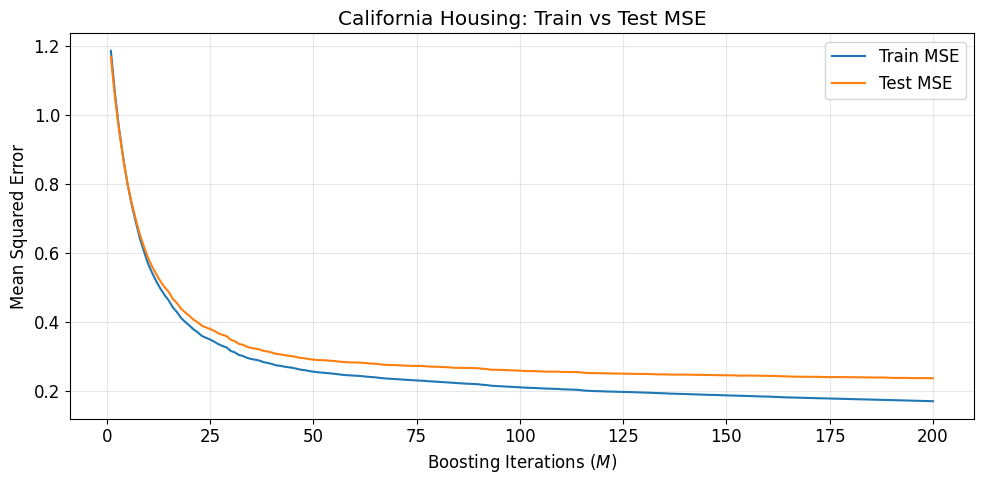

In [ ]:
_ = plot_regression_learning_curve(model_cal, X_cal_train, y_cal_train, X_cal_test, y_cal_test,
                               'California Housing: Train vs Test MSE')

## 4.2 Dataset 2: Friedman #1 (Synthetic)

The true function is $y = 10 \sin(\pi x_1 x_2) + 20(x_3 - 0.5)^2 + 10 x_4 + 5 x_5 + \varepsilon$. This is useful because the ground truth is known, so we can assess how well boosting recovers the nonlinear structure.

In [ ]:
X_fr, y_fr = make_friedman1(n_samples=5000, n_features=10, noise=1.0, random_state=42)
X_fr_train, X_fr_test, y_fr_train, y_fr_test = train_test_split(
    X_fr, y_fr, test_size=0.2, random_state=42
)
print(f"Friedman #1: {X_fr_train.shape[0]} train, {X_fr_test.shape[0]} test, {X_fr.shape[1]} features")

Friedman #1: 4000 train, 1000 test, 10 features


In [ ]:
model_fr = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, loss='squared')
model_fr.fit(X_fr_train, y_fr_train)
evaluate_regression(model_fr, X_fr_train, y_fr_train, X_fr_test, y_fr_test,
                    "Friedman #1 — Squared Error Loss")

  Friedman #1 — Squared Error Loss
  Train MSE : 0.6414
  Test  MSE : 1.5384
  Train MAE : 0.6355
  Test  MAE : 0.9774
  Train R²  : 0.9741
  Test  R²  : 0.9376


1.53840110929289

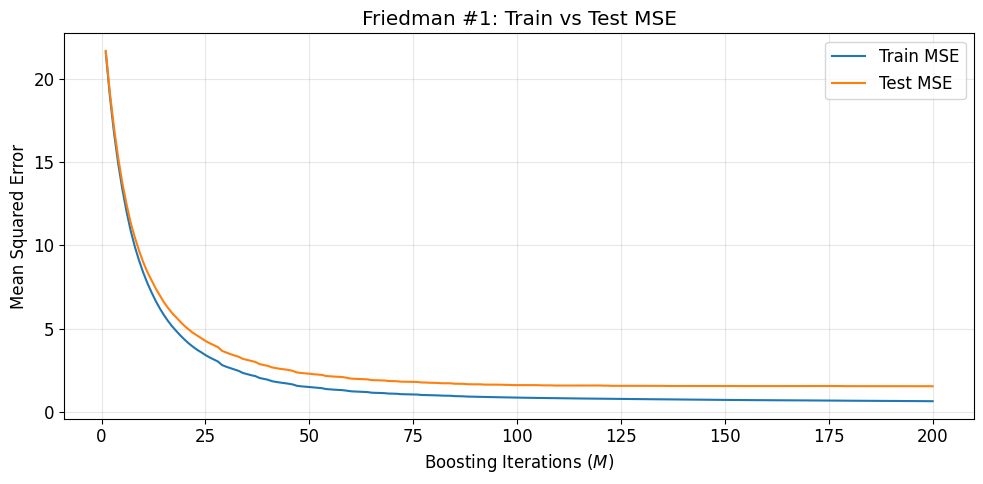

In [ ]:
_ = plot_regression_learning_curve(model_fr, X_fr_train, y_fr_train, X_fr_test, y_fr_test,
                               'Friedman #1: Train vs Test MSE')

---
# Part 5: Classification Experiments

## 5.1 Dataset 1: Digits ($K = 10$)

The Digits dataset contains 8×8 grayscale images of handwritten digits (0–9), with 64 pixel-intensity features. This is a substantially harder multi-class problem ($K=10$) compared to 3-class datasets, making it ideal for demonstrating the value of boosting over single trees.

In [ ]:
digits = load_digits()
X_dig, y_dig = digits.data, digits.target
X_dig_train, X_dig_test, y_dig_train, y_dig_test = train_test_split(
    X_dig, y_dig, test_size=0.3, random_state=42
)
print(f"Digits: {X_dig_train.shape[0]} train, {X_dig_test.shape[0]} test, K={len(np.unique(y_dig))}, features={X_dig.shape[1]}")

Digits: 1257 train, 540 test, K=10, features=64


In [ ]:
model_dig = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model_dig.fit(X_dig_train, y_dig_train)
evaluate_classification(model_dig, X_dig_train, y_dig_train, X_dig_test, y_dig_test,
                        "Digits — Gradient Boosting (K=10)")

  Digits — Gradient Boosting (K=10)
  Train Accuracy : 1.0000
  Test  Accuracy : 0.9704

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       1.00      1.00      1.00        50
           2       1.00      0.98      0.99        47
           3       1.00      0.96      0.98        54
           4       0.98      0.97      0.97        60
           5       0.98      0.95      0.97        66
           6       0.96      0.96      0.96        53
           7       0.95      0.98      0.96        55
           8       0.90      1.00      0.95        43
           9       0.93      0.93      0.93        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



0.9703703703703703

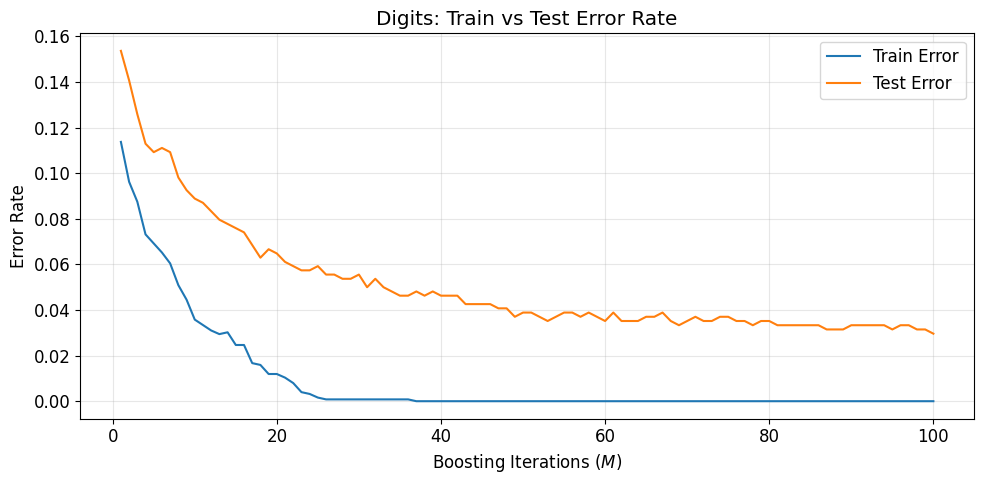

In [ ]:
_ = plot_classification_learning_curve(model_dig, X_dig_train, y_dig_train, X_dig_test, y_dig_test,
                                   'Digits: Train vs Test Error Rate')

### Confusion Matrix

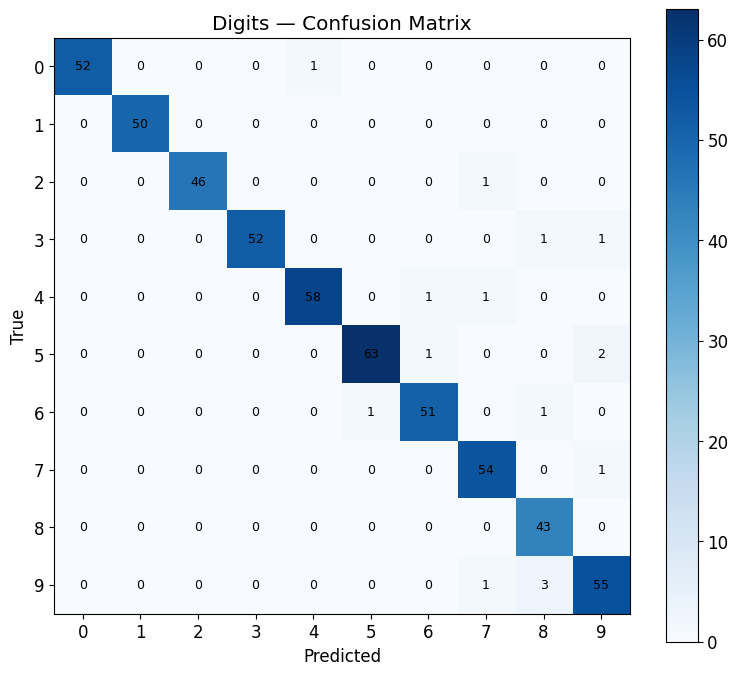

In [ ]:
pred_dig = model_dig.predict(X_dig_test)
cm = confusion_matrix(y_dig_test, pred_dig)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=9)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Digits — Confusion Matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5.2 Dataset 2: Wine ($K = 3$)

In [ ]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Standardize features for better tree splits
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine_scaled, y_wine, test_size=0.3, random_state=42
)
print(f"Wine: {X_w_train.shape[0]} train, {X_w_test.shape[0]} test, K={len(np.unique(y_wine))}")

Wine: 124 train, 54 test, K=3


In [ ]:
model_wine = GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.1)
model_wine.fit(X_w_train, y_w_train)
evaluate_classification(model_wine, X_w_train, y_w_train, X_w_test, y_w_test,
                        "Wine — Gradient Boosting (K=3)")

  Wine — Gradient Boosting (K=3)
  Train Accuracy : 1.0000
  Test  Accuracy : 0.9815

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



0.9814814814814815

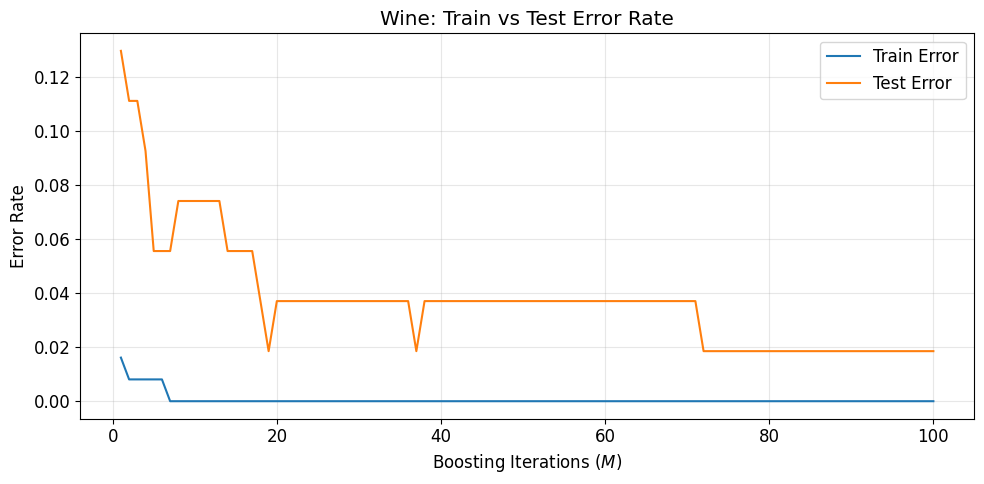

In [ ]:
_ = plot_classification_learning_curve(model_wine, X_w_train, y_w_train, X_w_test, y_w_test,
                                   'Wine: Train vs Test Error Rate')

### Confusion Matrix

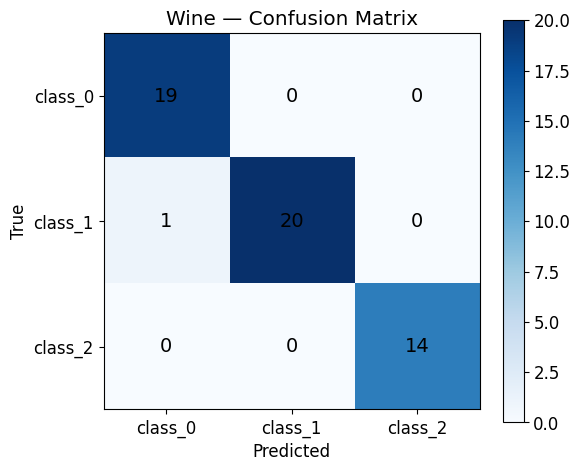

In [ ]:
pred_wine = model_wine.predict(X_w_test)
cm = confusion_matrix(y_w_test, pred_wine)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(wine.target_names); ax.set_yticklabels(wine.target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Wine — Confusion Matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
# Part 6: Hyperparameter Analysis

## 6.1 Effect of Number of Boosting Iterations $M$

As $M$ increases, the training error continues to decrease. However, the test error eventually plateaus or increases, indicating overfitting. The optimal $M$ balances bias and variance.

M=  10 | Train MSE: 0.5699 | Test MSE: 0.5867
M=  25 | Train MSE: 0.3500 | Test MSE: 0.3808
M=  50 | Train MSE: 0.2567 | Test MSE: 0.2910
M= 100 | Train MSE: 0.2113 | Test MSE: 0.2592
M= 200 | Train MSE: 0.1712 | Test MSE: 0.2370
M= 300 | Train MSE: 0.1481 | Test MSE: 0.2283
M= 400 | Train MSE: 0.1316 | Test MSE: 0.2240
M= 500 | Train MSE: 0.1194 | Test MSE: 0.2196


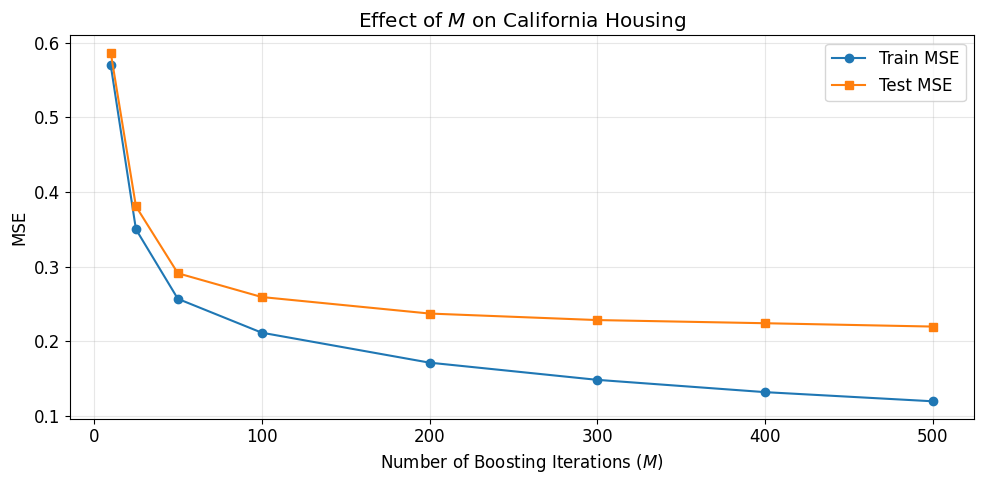

In [ ]:
# Regression: California Housing
M_values = [10, 25, 50, 100, 200, 300, 400, 500]
train_mses, test_mses = [], []

for M in M_values:
    model = GradientBoostingRegressor(n_estimators=M, max_depth=4, learning_rate=0.1, loss='squared')
    model.fit(X_cal_train, y_cal_train)
    train_mses.append(mean_squared_error(y_cal_train, model.predict(X_cal_train)))
    test_mses.append(mean_squared_error(y_cal_test, model.predict(X_cal_test)))
    print(f"M={M:>4d} | Train MSE: {train_mses[-1]:.4f} | Test MSE: {test_mses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(M_values, train_mses, 'o-', label='Train MSE')
ax.plot(M_values, test_mses, 's-', label='Test MSE')
ax.set_xlabel('Number of Boosting Iterations ($M$)')
ax.set_ylabel('MSE')
ax.set_title('Effect of $M$ on California Housing')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

M=   5 | Train Acc: 0.9292 | Test Acc: 0.8907
M=  10 | Train Acc: 0.9634 | Test Acc: 0.9093
M=  25 | Train Acc: 0.9984 | Test Acc: 0.9407
M=  50 | Train Acc: 1.0000 | Test Acc: 0.9611
M= 100 | Train Acc: 1.0000 | Test Acc: 0.9685
M= 150 | Train Acc: 1.0000 | Test Acc: 0.9741
M= 200 | Train Acc: 1.0000 | Test Acc: 0.9741


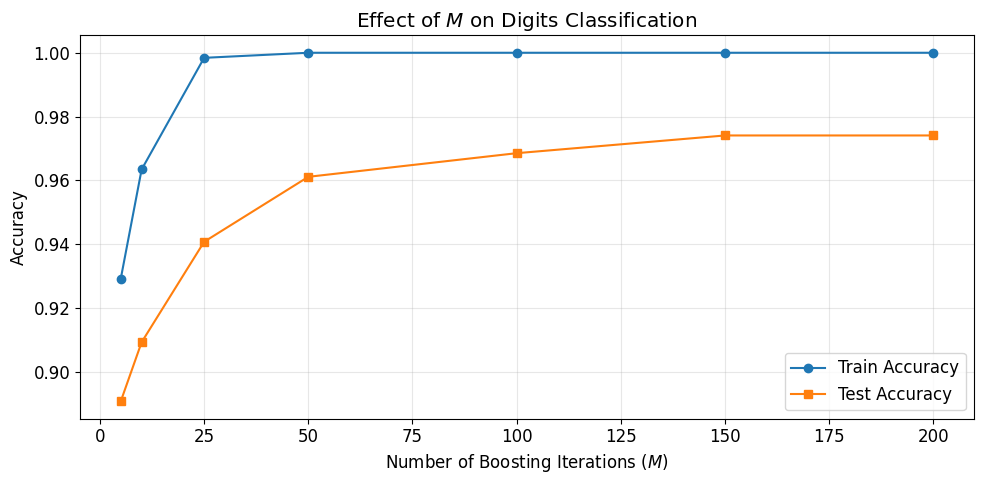

In [ ]:
# Classification: Digits
M_values_clf = [5, 10, 25, 50, 100, 150, 200]
train_accs, test_accs = [], []

for M in M_values_clf:
    model = GradientBoostingClassifier(n_estimators=M, max_depth=3, learning_rate=0.1)
    model.fit(X_dig_train, y_dig_train)
    tr_acc = accuracy_score(y_dig_train, model.predict(X_dig_train))
    te_acc = accuracy_score(y_dig_test, model.predict(X_dig_test))
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"M={M:>4d} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(M_values_clf, train_accs, 'o-', label='Train Accuracy')
ax.plot(M_values_clf, test_accs, 's-', label='Test Accuracy')
ax.set_xlabel('Number of Boosting Iterations ($M$)')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of $M$ on Digits Classification')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.2 Effect of Tree Depth $J$ (Interaction Depth)

The number of terminal nodes $J$ controls the interaction order of the model. A stump ($J=2$, i.e., `max_depth=1`) produces a purely additive model with no interactions. Depth $d$ allows up to $d$-way interactions between variables.

depth=1 | Train MSE: 0.3949 | Test MSE: 0.4222
depth=2 | Train MSE: 0.2694 | Test MSE: 0.3029
depth=3 | Train MSE: 0.2194 | Test MSE: 0.2615
depth=4 | Train MSE: 0.1712 | Test MSE: 0.2373
depth=5 | Train MSE: 0.1294 | Test MSE: 0.2229
depth=6 | Train MSE: 0.0897 | Test MSE: 0.2142
depth=8 | Train MSE: 0.0318 | Test MSE: 0.2087


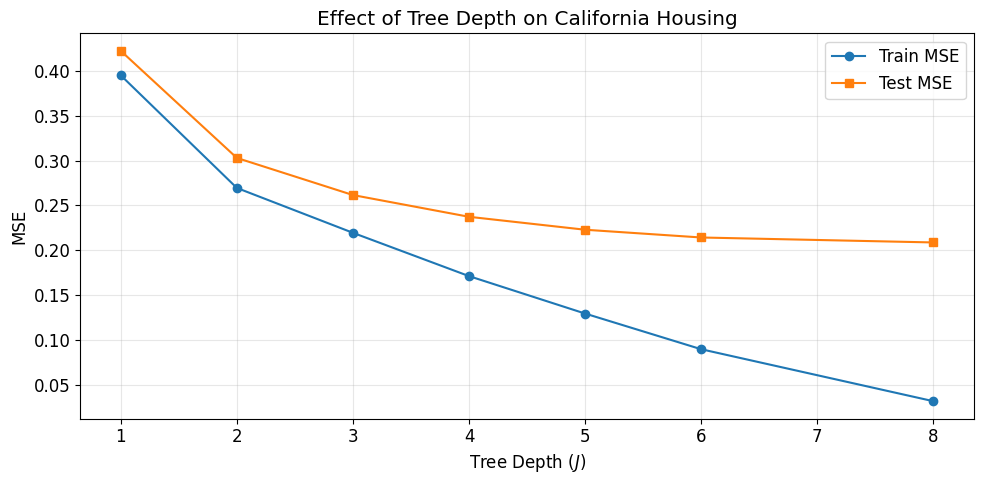

In [ ]:
depths = [1, 2, 3, 4, 5, 6, 8]
train_mses_d, test_mses_d = [], []

for d in depths:
    model = GradientBoostingRegressor(n_estimators=200, max_depth=d, learning_rate=0.1, loss='squared')
    model.fit(X_cal_train, y_cal_train)
    train_mses_d.append(mean_squared_error(y_cal_train, model.predict(X_cal_train)))
    test_mses_d.append(mean_squared_error(y_cal_test, model.predict(X_cal_test)))
    print(f"depth={d} | Train MSE: {train_mses_d[-1]:.4f} | Test MSE: {test_mses_d[-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_mses_d, 'o-', label='Train MSE')
ax.plot(depths, test_mses_d, 's-', label='Test MSE')
ax.set_xlabel('Tree Depth ($J$)')
ax.set_ylabel('MSE')
ax.set_title('Effect of Tree Depth on California Housing')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.3 Effect of Learning Rate $\nu$ (Shrinkage)

The shrinkage parameter $\nu$ scales each tree's contribution:

$$f_m(x) = f_{m-1}(x) + \nu \cdot \sum_{j=1}^{J_m} \gamma_{jm} I(x \in R_{jm})$$

Smaller $\nu$ requires more iterations to achieve the same training loss, but typically results in better generalization. There is a tradeoff between $\nu$ and $M$: reducing $\nu$ by a factor of 10 roughly requires 10x more iterations.

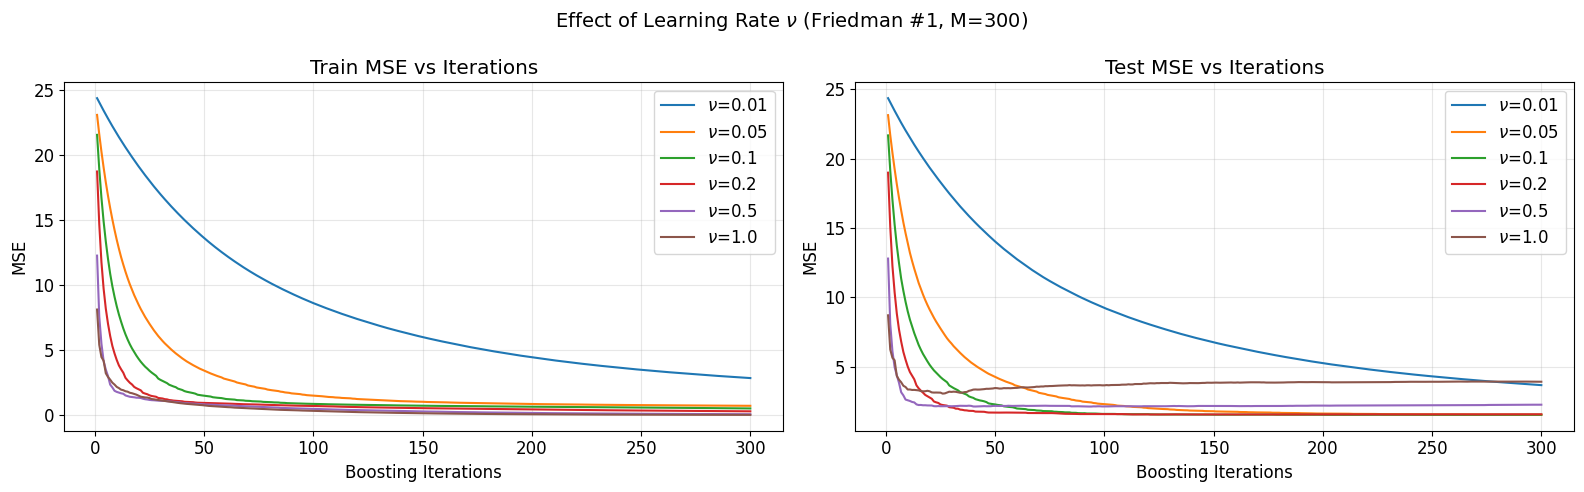

In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
M_fixed = 300

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for lr in learning_rates:
    model = GradientBoostingRegressor(n_estimators=M_fixed, max_depth=4, learning_rate=lr, loss='squared')
    model.fit(X_fr_train, y_fr_train)

    test_mse = []
    train_mse = []
    for pt, pe in zip(model.staged_predict(X_fr_train), model.staged_predict(X_fr_test)):
        train_mse.append(mean_squared_error(y_fr_train, pt))
        test_mse.append(mean_squared_error(y_fr_test, pe))

    axes[0].plot(range(1, M_fixed+1), train_mse, label=f'$\\nu$={lr}')
    axes[1].plot(range(1, M_fixed+1), test_mse, label=f'$\\nu$={lr}')

axes[0].set_title('Train MSE vs Iterations')
axes[0].set_xlabel('Boosting Iterations'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Test MSE vs Iterations')
axes[1].set_xlabel('Boosting Iterations'); axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Effect of Learning Rate $\\nu$ (Friedman #1, M={M_fixed})', fontsize=14)
plt.tight_layout()
plt.show()

## 6.4 Effect of Loss Function (Regression)

We compare squared error, absolute error, and Huber loss on data **with injected outliers** to demonstrate the robustness advantage of Huber and absolute error losses.

In [ ]:
# Create a version of Friedman data with outliers
np.random.seed(42)
y_fr_train_noisy = y_fr_train.copy()
outlier_idx = np.random.choice(len(y_fr_train), size=int(0.05 * len(y_fr_train)), replace=False)
y_fr_train_noisy[outlier_idx] += np.random.normal(0, 30, size=len(outlier_idx))

print(f"Injected {len(outlier_idx)} outliers (5% of training data) with std=30")

Injected 200 outliers (5% of training data) with std=30


In [ ]:
losses = ['squared', 'absolute', 'huber']
results_loss = {}

for loss_name in losses:
    model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, loss=loss_name)
    model.fit(X_fr_train, y_fr_train_noisy)
    pred = model.predict(X_fr_test)
    mse = mean_squared_error(y_fr_test, pred)
    mae = mean_absolute_error(y_fr_test, pred)
    results_loss[loss_name] = {'mse': mse, 'mae': mae, 'model': model}
    print(f"{loss_name:>10s} | Test MSE: {mse:.4f} | Test MAE: {mae:.4f}")

   squared | Test MSE: 7.6816 | Test MAE: 1.7536
  absolute | Test MSE: 1.7024 | Test MAE: 1.0317
     huber | Test MSE: 1.8476 | Test MAE: 1.0619


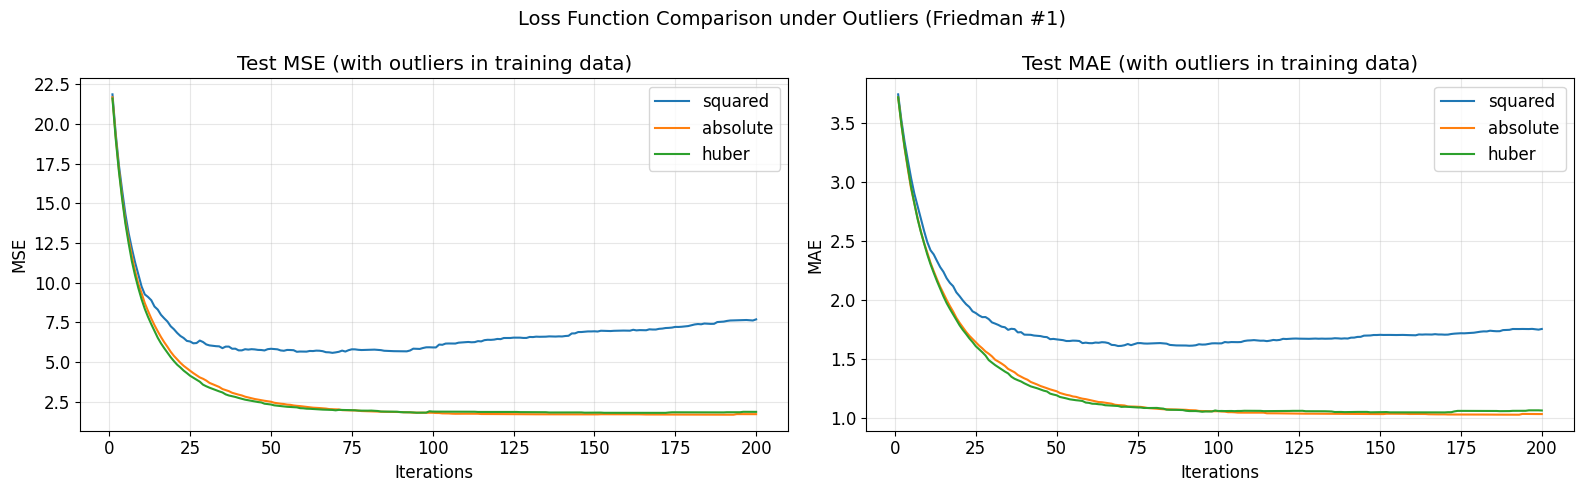

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for loss_name in losses:
    model = results_loss[loss_name]['model']
    test_mse_curve = []
    test_mae_curve = []
    for pred in model.staged_predict(X_fr_test):
        test_mse_curve.append(mean_squared_error(y_fr_test, pred))
        test_mae_curve.append(mean_absolute_error(y_fr_test, pred))
    axes[0].plot(range(1, len(test_mse_curve)+1), test_mse_curve, label=loss_name)
    axes[1].plot(range(1, len(test_mae_curve)+1), test_mae_curve, label=loss_name)

axes[0].set_title('Test MSE (with outliers in training data)')
axes[0].set_xlabel('Iterations'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Test MAE (with outliers in training data)')
axes[1].set_xlabel('Iterations'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle('Loss Function Comparison under Outliers (Friedman #1)', fontsize=14)
plt.tight_layout()
plt.show()

---
# Part 7: Comparison with Baselines

We compare our gradient boosted model against:
- **Single Decision Stump** (`max_depth=1`): a weak learner baseline
- **Single Deep Tree** (`max_depth=None`): an overfit baseline
- **Boosted Stumps**: gradient boosting with `max_depth=1`
- **Boosted Trees (depth=4)**: our standard model

This mirrors the comparison in Figure 10.2 of ESL.

## 7.1 Regression Baselines (California Housing / Fallback)

In [ ]:
# Single Stump
stump_reg = DecisionTreeRegressor(max_depth=1)
stump_reg.fit(X_cal_train, y_cal_train)
stump_mse = mean_squared_error(y_cal_test, stump_reg.predict(X_cal_test))
stump_r2 = r2_score(y_cal_test, stump_reg.predict(X_cal_test))

# Single Deep Tree
deep_tree = DecisionTreeRegressor(max_depth=None)
deep_tree.fit(X_cal_train, y_cal_train)
deep_mse = mean_squared_error(y_cal_test, deep_tree.predict(X_cal_test))
deep_r2 = r2_score(y_cal_test, deep_tree.predict(X_cal_test))

# Boosted Stumps
boosted_stumps_reg = GradientBoostingRegressor(n_estimators=300, max_depth=1, learning_rate=0.1)
boosted_stumps_reg.fit(X_cal_train, y_cal_train)
bstump_mse = mean_squared_error(y_cal_test, boosted_stumps_reg.predict(X_cal_test))
bstump_r2 = r2_score(y_cal_test, boosted_stumps_reg.predict(X_cal_test))

# Boosted Trees (depth=4)
boosted_trees_reg = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.1)
boosted_trees_reg.fit(X_cal_train, y_cal_train)
btree_mse = mean_squared_error(y_cal_test, boosted_trees_reg.predict(X_cal_test))
btree_r2 = r2_score(y_cal_test, boosted_trees_reg.predict(X_cal_test))

print(f"{'Model':<25s} | {'Test MSE':>10s} | {'Test R²':>10s}")
print('-' * 52)
print(f"{'Single Stump':<25s} | {stump_mse:>10.4f} | {stump_r2:>10.4f}")
print(f"{'Single Deep Tree':<25s} | {deep_mse:>10.4f} | {deep_r2:>10.4f}")
print(f"{'Boosted Stumps (d=1)':<25s} | {bstump_mse:>10.4f} | {bstump_r2:>10.4f}")
print(f"{'Boosted Trees (d=4)':<25s} | {btree_mse:>10.4f} | {btree_r2:>10.4f}")

Model                     |   Test MSE |    Test R²
----------------------------------------------------
Single Stump              |     0.9441 |     0.2795
Single Deep Tree          |     0.4958 |     0.6216
Boosted Stumps (d=1)      |     0.3953 |     0.6983
Boosted Trees (d=4)       |     0.2279 |     0.8261


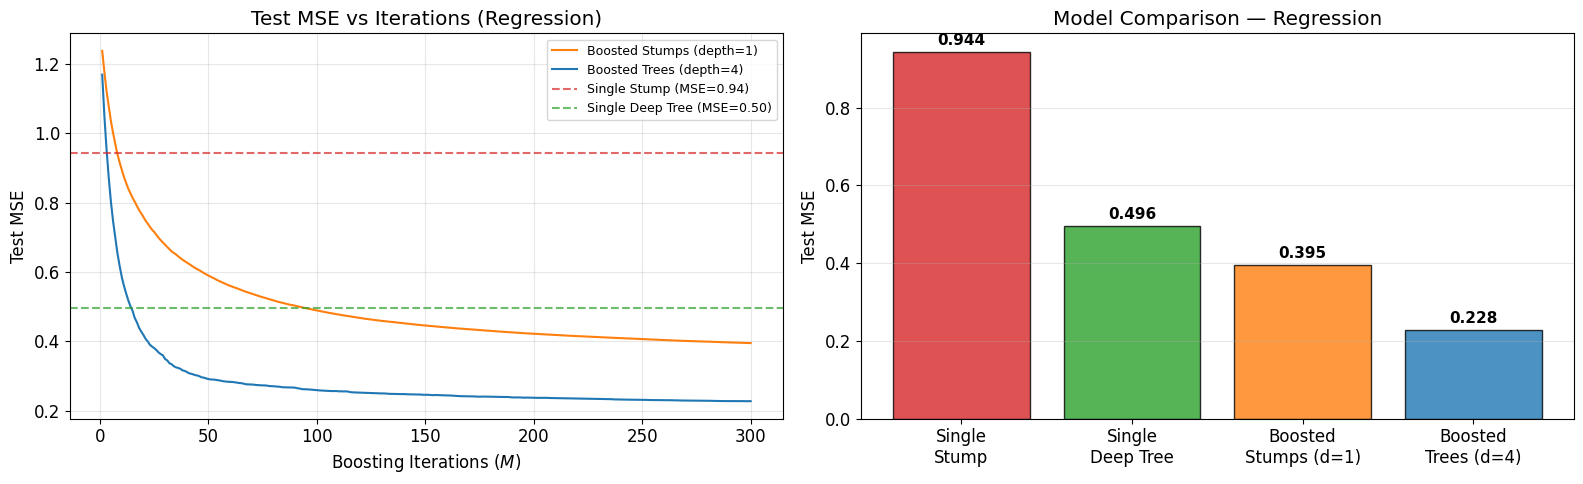

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Learning curves ---
test_mse_stumps = [mean_squared_error(y_cal_test, p) for p in boosted_stumps_reg.staged_predict(X_cal_test)]
axes[0].plot(range(1, 301), test_mse_stumps, label='Boosted Stumps (depth=1)', color='tab:orange')

test_mse_trees = [mean_squared_error(y_cal_test, p) for p in boosted_trees_reg.staged_predict(X_cal_test)]
axes[0].plot(range(1, 301), test_mse_trees, label='Boosted Trees (depth=4)', color='tab:blue')

axes[0].axhline(y=stump_mse, color='tab:red', linestyle='--', alpha=0.7,
           label=f'Single Stump (MSE={stump_mse:.2f})')
axes[0].axhline(y=deep_mse, color='tab:green', linestyle='--', alpha=0.7,
           label=f'Single Deep Tree (MSE={deep_mse:.2f})')

axes[0].set_xlabel('Boosting Iterations ($M$)')
axes[0].set_ylabel('Test MSE')
axes[0].set_title('Test MSE vs Iterations (Regression)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Right: Bar chart comparison ---
models_names = ['Single\nStump', 'Single\nDeep Tree', 'Boosted\nStumps (d=1)', 'Boosted\nTrees (d=4)']
mses = [stump_mse, deep_mse, bstump_mse, btree_mse]
colors = ['tab:red', 'tab:green', 'tab:orange', 'tab:blue']

bars = axes[1].bar(models_names, mses, color=colors, edgecolor='black', alpha=0.8)
for bar, mse in zip(bars, mses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{mse:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Test MSE')
axes[1].set_title('Model Comparison — Regression')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7.2 Classification Baselines (Digits)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Single Stump
stump_clf = DecisionTreeClassifier(max_depth=1)
stump_clf.fit(X_dig_train, y_dig_train)
stump_acc = accuracy_score(y_dig_test, stump_clf.predict(X_dig_test))

# Single Deep Tree
deep_clf = DecisionTreeClassifier(max_depth=None)
deep_clf.fit(X_dig_train, y_dig_train)
deep_acc = accuracy_score(y_dig_test, deep_clf.predict(X_dig_test))

# Boosted Stumps
boosted_stumps_clf = GradientBoostingClassifier(n_estimators=200, max_depth=1, learning_rate=0.1)
boosted_stumps_clf.fit(X_dig_train, y_dig_train)
boosted_stumps_acc = accuracy_score(y_dig_test, boosted_stumps_clf.predict(X_dig_test))

# Boosted Trees (depth=3)
boosted_trees_clf = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1)
boosted_trees_clf.fit(X_dig_train, y_dig_train)
boosted_trees_acc = accuracy_score(y_dig_test, boosted_trees_clf.predict(X_dig_test))

print(f"{'Model':<25s} | {'Test Acc':>10s} | {'Test Error':>10s}")
print('-' * 52)
print(f"{'Single Stump':<25s} | {stump_acc:>10.4f} | {1-stump_acc:>10.4f}")
print(f"{'Single Deep Tree':<25s} | {deep_acc:>10.4f} | {1-deep_acc:>10.4f}")
print(f"{'Boosted Stumps (d=1)':<25s} | {boosted_stumps_acc:>10.4f} | {1-boosted_stumps_acc:>10.4f}")
print(f"{'Boosted Trees (d=3)':<25s} | {boosted_trees_acc:>10.4f} | {1-boosted_trees_acc:>10.4f}")

Model                     |   Test Acc | Test Error
----------------------------------------------------
Single Stump              |     0.1870 |     0.8130
Single Deep Tree          |     0.8333 |     0.1667
Boosted Stumps (d=1)      |     0.9463 |     0.0537
Boosted Trees (d=3)       |     0.9741 |     0.0259


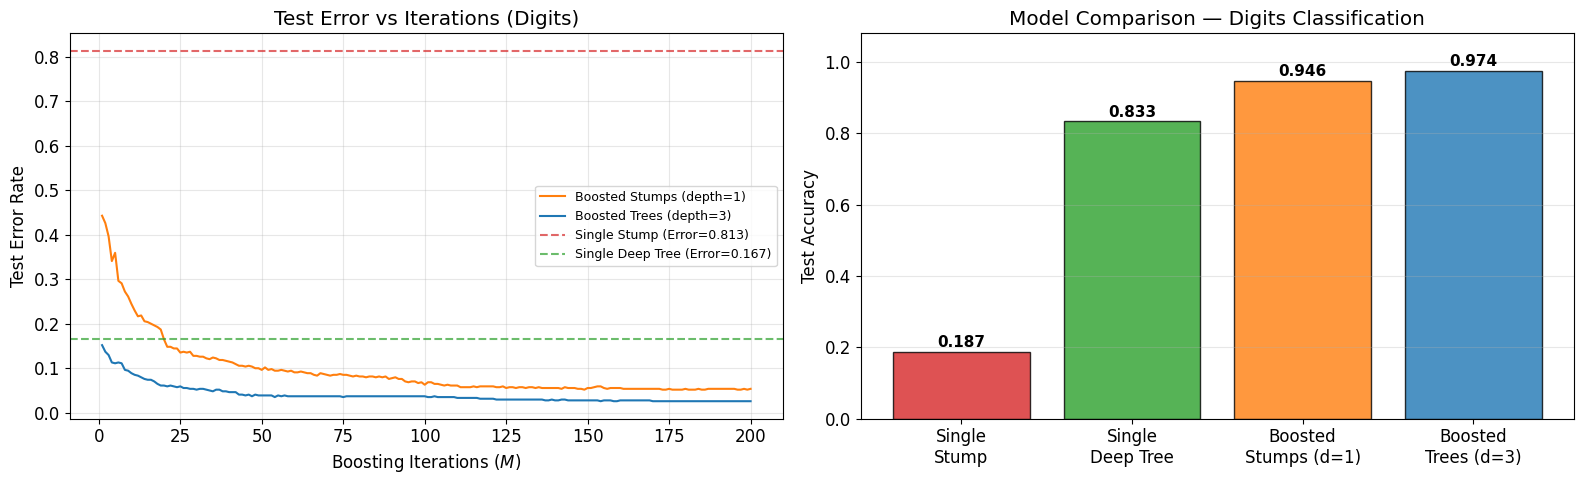

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Learning curves ---
test_err_stumps = [1 - accuracy_score(y_dig_test, p) for p in boosted_stumps_clf.staged_predict(X_dig_test)]
axes[0].plot(range(1, 201), test_err_stumps, label='Boosted Stumps (depth=1)', color='tab:orange')

test_err_trees = [1 - accuracy_score(y_dig_test, p) for p in boosted_trees_clf.staged_predict(X_dig_test)]
axes[0].plot(range(1, 201), test_err_trees, label='Boosted Trees (depth=3)', color='tab:blue')

axes[0].axhline(y=1-stump_acc, color='tab:red', linestyle='--', alpha=0.7,
           label=f'Single Stump (Error={1-stump_acc:.3f})')
axes[0].axhline(y=1-deep_acc, color='tab:green', linestyle='--', alpha=0.7,
           label=f'Single Deep Tree (Error={1-deep_acc:.3f})')

axes[0].set_xlabel('Boosting Iterations ($M$)')
axes[0].set_ylabel('Test Error Rate')
axes[0].set_title('Test Error vs Iterations (Digits)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Right: Bar chart comparison ---
models_names = ['Single\nStump', 'Single\nDeep Tree', 'Boosted\nStumps (d=1)', 'Boosted\nTrees (d=3)']
accs = [stump_acc, deep_acc, boosted_stumps_acc, boosted_trees_acc]
colors = ['tab:red', 'tab:green', 'tab:orange', 'tab:blue']

bars = axes[1].bar(models_names, accs, color=colors, edgecolor='black', alpha=0.8)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Model Comparison — Digits Classification')
axes[1].set_ylim(0, 1.08)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
# Part 8: Combined Hyperparameter Interaction

We examine the joint effect of learning rate $\nu$ and tree depth by computing the best test MSE achieved over all iterations for each combination.

In [ ]:
depths_grid = [1, 2, 3, 4, 6]
lr_grid = [0.01, 0.05, 0.1, 0.2]
M_grid = 300

results_grid = np.zeros((len(depths_grid), len(lr_grid)))

for i, d in enumerate(depths_grid):
    for j, lr in enumerate(lr_grid):
        model = GradientBoostingRegressor(n_estimators=M_grid, max_depth=d, learning_rate=lr, loss='squared')
        model.fit(X_fr_train, y_fr_train)
        # Best test MSE across all stages
        best_mse = min(mean_squared_error(y_fr_test, p) for p in model.staged_predict(X_fr_test))
        results_grid[i, j] = best_mse
        print(f"depth={d}, lr={lr:.2f} | Best Test MSE: {best_mse:.4f}")

depth=1, lr=0.01 | Best Test MSE: 11.2964
depth=1, lr=0.05 | Best Test MSE: 3.9412
depth=1, lr=0.10 | Best Test MSE: 3.1410
depth=1, lr=0.20 | Best Test MSE: 3.1029
depth=2, lr=0.01 | Best Test MSE: 6.9629
depth=2, lr=0.05 | Best Test MSE: 2.3113
depth=2, lr=0.10 | Best Test MSE: 1.6029
depth=2, lr=0.20 | Best Test MSE: 1.5720
depth=3, lr=0.01 | Best Test MSE: 4.7459
depth=3, lr=0.05 | Best Test MSE: 1.7181
depth=3, lr=0.10 | Best Test MSE: 1.5022
depth=3, lr=0.20 | Best Test MSE: 1.5450
depth=4, lr=0.01 | Best Test MSE: 3.6809
depth=4, lr=0.05 | Best Test MSE: 1.5526
depth=4, lr=0.10 | Best Test MSE: 1.5358
depth=4, lr=0.20 | Best Test MSE: 1.5590
depth=6, lr=0.01 | Best Test MSE: 2.4621
depth=6, lr=0.05 | Best Test MSE: 1.6344
depth=6, lr=0.10 | Best Test MSE: 1.6415
depth=6, lr=0.20 | Best Test MSE: 1.7679


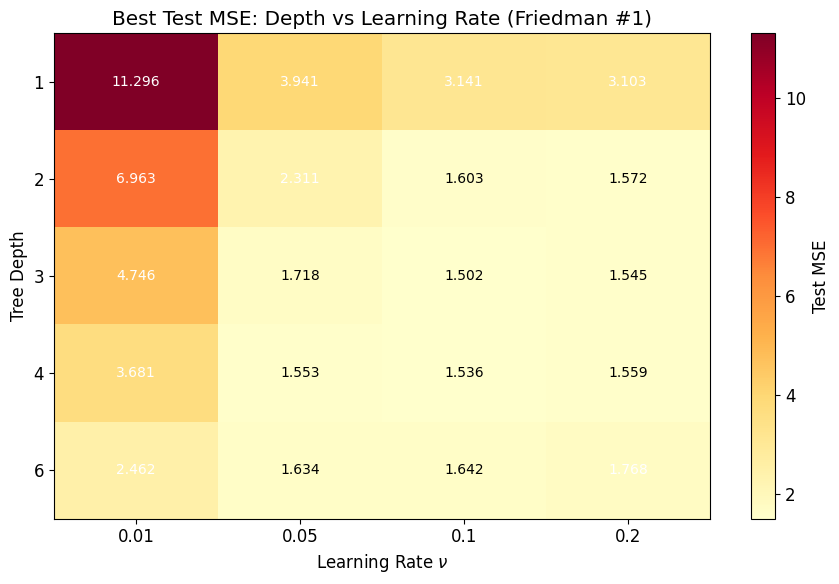

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(results_grid, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(lr_grid)))
ax.set_xticklabels([f'{lr}' for lr in lr_grid])
ax.set_yticks(range(len(depths_grid)))
ax.set_yticklabels([f'{d}' for d in depths_grid])
ax.set_xlabel('Learning Rate $\\nu$')
ax.set_ylabel('Tree Depth')
ax.set_title('Best Test MSE: Depth vs Learning Rate (Friedman #1)')

for i in range(len(depths_grid)):
    for j in range(len(lr_grid)):
        ax.text(j, i, f'{results_grid[i,j]:.3f}', ha='center', va='center', fontsize=10,
                color='white' if results_grid[i,j] > np.median(results_grid) else 'black')

plt.colorbar(im, ax=ax, label='Test MSE')
plt.tight_layout()
plt.show()

---
# Part 9: Training Loss Convergence

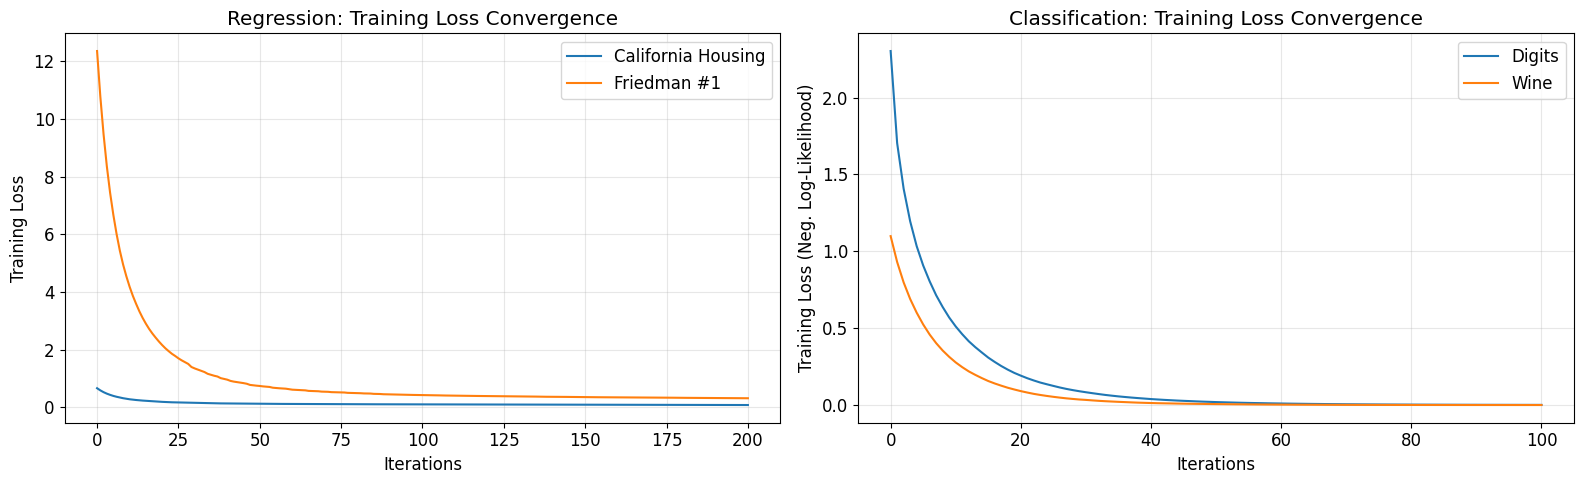

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression training loss
axes[0].plot(model_cal.train_losses, label='California Housing')
axes[0].plot(model_fr.train_losses, label='Friedman #1')
axes[0].set_xlabel('Iterations'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Regression: Training Loss Convergence')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Classification training loss
axes[1].plot(model_dig.train_losses, label='Digits')
axes[1].plot(model_wine.train_losses, label='Wine')
axes[1].set_xlabel('Iterations'); axes[1].set_ylabel('Training Loss (Neg. Log-Likelihood)')
axes[1].set_title('Classification: Training Loss Convergence')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 10: Predicted Probability Evolution (Classification)

We track how the predicted class probabilities evolve across boosting iterations for a single test sample. This illustrates how the softmax outputs converge as more trees are added.

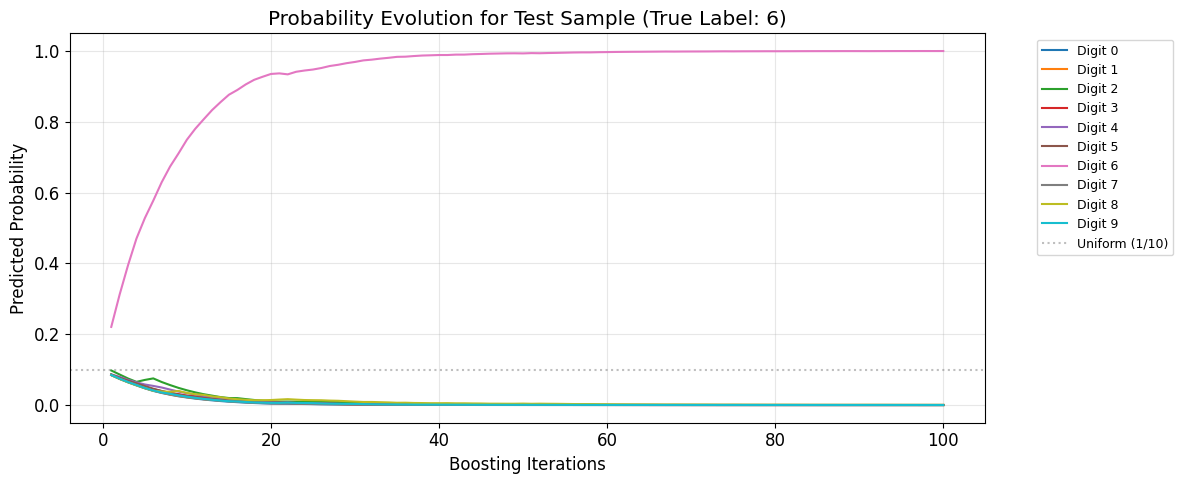

In [ ]:
sample_idx = 0
true_label = y_dig_test[sample_idx]

probs_over_time = []
for probs in model_dig.staged_predict_proba(X_dig_test):
    probs_over_time.append(probs[sample_idx].copy())

probs_over_time = np.array(probs_over_time)

fig, ax = plt.subplots(figsize=(12, 5))
for k in range(10):
    ax.plot(range(1, len(probs_over_time)+1), probs_over_time[:, k],
            label=f'Digit {k}')

ax.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5, label='Uniform (1/10)')
ax.set_xlabel('Boosting Iterations')
ax.set_ylabel('Predicted Probability')
ax.set_title(f'Probability Evolution for Test Sample (True Label: {true_label})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()